---
title: Random Forest vs. Linear Regression Comparison
author: Andrei Akopian
date: 2026-04-04
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true

---

This is a comparison of how well Linear Regression performs compared to RF, and the predictions are poor for the same points.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy
import numpy as np

In [3]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[2]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [4]:
LAB_DATA = "../../../data/useful_columns_data.csv"
ATMO_DATA = "../../../data/isprs_26_only_vza_rows.csv"

In [5]:
df = helper_functions.open_file(LAB_DATA)
fractions, lb900to1700_raw = helper_functions.take_subset(df,start=900,end=1700)

# Simple Residual Correlation Comparison with state 42

In [6]:
dataset = lb900to1700_raw
# norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
norms = dataset.sum(axis=1).to_numpy()
print(norms.min(), norms.max())
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
# post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
post_norms = normalized_dataset.sum(axis=1)
print(post_norms.min(), post_norms.max())
lb900to1700 = normalized_dataset

8.705963602199999 45.08746808780001
0.9999999999999989 1.0000000000000013


In [7]:
# split the data as usual
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(lb900to1700, fractions.to_numpy(), test_size=0.2, random_state=42)

In [8]:
rf = sklearn.ensemble.RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    max_features = 13,
    min_samples_split=3,
    min_samples_leaf=1,
    min_impurity_decrease=0.0,
    min_weight_fraction_leaf=0.0,
    random_state = 42,
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,18
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,13
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
normalized_regression = sklearn.linear_model.LinearRegression()
normalized_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# lienear regression predictions
ab_predictions = normalized_regression.predict(X_test)
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
lr_predictions = ab_clipped_predictions / ab_clipped_predictions.sum(axis=1)[:, np.newaxis]
lr_residuals = y_test - lr_predictions
# helper_functions.plot_preds(
#     ab_true=y_test,
#     ab_pred=ab_clipped_predictions,
#     model_name="Normalized Linear Regression",
# )

In [11]:
# rf predictions
rf_predictions = rf.predict(X_test)
rf_residuals = y_test - rf_predictions

Restructure predictions for a scatter plot.

In [30]:
rf_npv_residuals = rf_residuals[:,0]
rf_gv_residuals = rf_residuals[:,1]
rf_soil_residuals = rf_residuals[:,2]

lr_npv_residuals = lr_residuals[:,0]
lr_gv_residuals = lr_residuals[:,1]
lr_soil_residuals = lr_residuals[:,2]

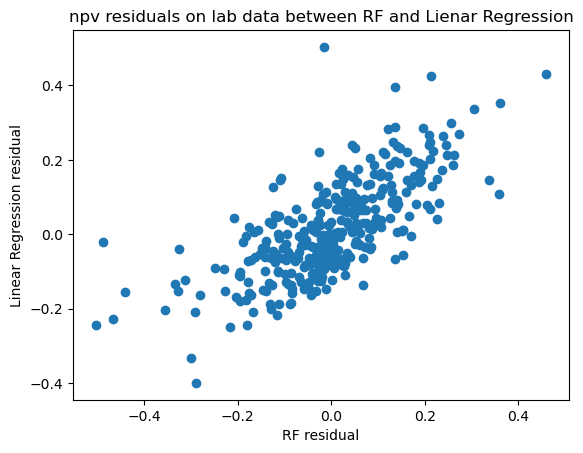

In [40]:
target = "npv"
settings = {
    "npv" : (rf_npv_residuals, lr_npv_residuals, "npv"),
    "gv" : (rf_gv_residuals, lr_gv_residuals, "gv"),
    "soil" : (rf_soil_residuals, lr_soil_residuals, "soil")
}
setting = settings[target]
plt.scatter(setting[0], setting[1])
plt.xlabel("RF residual")
plt.ylabel("Linear Regression residual")
plt.title(f"{setting[2]} residuals on lab data between RF and Lienar Regression")
plt.show()